# Load libraries

**NOTE**: `tensorflow` and `keras` are *only* used to be able to import the MNIST dataset

In [25]:
import numpy as np
import matplotlib.pyplot as PLT

from scipy.special import softmax,logsumexp

import tensorflow as tf
from tensorflow import keras

# Download data

In [26]:
from tensorflow.keras.datasets import mnist

# Training / validation data + labels
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print('Shape (training data):', x_train.shape)
print('Shape (valid/testing data):', x_valid.shape)


Shape (training data): (60000, 28, 28)
Shape (valid/testing data): (10000, 28, 28)


### Data pre-processing (normalization, etc.)

In [27]:
def stdPreproc(dIn,L=255.0, flagNorm=True, flagMean=True):

    dIn = dIn.astype("float")
    
    if flagNorm:
       dIn = dIn/L

    if flagMean:
       mean = np.mean(dIn, axis = 0)
       dIn -= mean
    
    return(dIn)

x_train = stdPreproc(x_train)
x_valid = stdPreproc(x_valid)

#### Visualization of a random element

Shape: (28, 28) label: 9


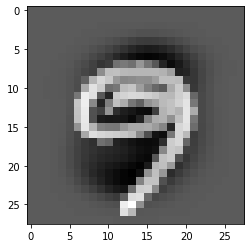

In [28]:
k = np.random.randint(0,x_train.shape[0])
    
PLT.imshow(x_train[k], cmap='gray')
print('Shape:',x_train[k].shape, 'label:', y_train[k])


#### Data vectorization

In [29]:
x_train = np.transpose( x_train.reshape(x_train.shape[0], x_train.shape[1]*x_train.shape[2]) )
x_valid = np.transpose( x_valid.reshape(x_valid.shape[0], x_valid.shape[1]*x_valid.shape[2]) )

# NOTE: in order to be consistant with lectures, then these matrices must be transpose


# Functions

Some useful functions are included here. For a full explanation see **Lecture 3b's Introduction**.

In [30]:
def softmax_L2_cost(X, Y, W, lmbd):

    fCost = np.sum(np.log(np.sum(np.exp(-X.transpose().dot(W)), axis=1)))
    fCost += np.sum( X*W[:,Y] )
    
    fCost /= float(X.shape[1])
    
    if lmbd > 0:
       fCost += lmbd*(sum( np.power(W.ravel(),2) ))
    
    return fCost

def softmax_L2_grad(X, Y, W, n, lmbd):
    
    z = X[:,np.ix_(n)].squeeze(1)      # select batch elements

    g = -z.dot( softmax(-z.transpose().dot(W),axis=1) )
    
    for k in range(len(n)):
        g[:,Y[n[k]] ] += z[:,k] 

    g /= float(len(n))  
    
    if lmbd > 0:
       g += lmbd*W
        
    return g
    
    
softmax_cost = lambda X,Y,W : softmax_L2_cost(X, Y, W, 0.)

softmax_grad = lambda X,Y,W,n : softmax_L2_grad(X, Y, W, n, 0.)
    
    

In [31]:
def computeSuccessSoftMax(X, Y, W):

    clase = -np.matmul(X.transpose(), W) 
    success = sum( np.argmax(clase,axis=1) == Y )
                
    return float(success)/float(X.shape[1])    
        
    

___

## Routines for SGD and variants

In [32]:
#%matplotlib qt

# Assumes that NetArch is a dictionary
def stochGD(X, Y, nEpochs, NetArch, alpha0=0.01, blkSize=32, flagVerbose=10):
    
    W = 0.01*np.random.randn(X.shape[0], NetArch['nClass'])
    
    fCost = np.zeros( (1,2) )
    fCost[0,1] = NetArch['cost'](X,Y,W)
    
    alpha = alpha0
    k = -1
    nBlk = np.floor_divide(X.shape[1],blkSize)         
    
    for e in range(nEpochs):

      if flagVerbose > 0:  
         print('\n')
         print("="*10)
         print('Epoch', e)
         print("="*10,'\n')
    
      # Generate permutation
      blkInd = 0
      perm = np.random.permutation(X.shape[1])
     
      last  = 0
      if np.remainder(X.shape[1],blkSize) > 0:
         last = 1 
                
      for b in range(nBlk):
        
        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:blkInd+blkSize]
        blkInd += blkSize
        
        # Compute the gradient
        g = NetArch['grad'](X, Y, W, n)
        
        # GD step
        W = W - alpha*g                     # In general
                                            # NetArch['prox'](W - alpha*g, alpha, lmbd)

        if flagVerbose > 0:
          if np.remainder(k,flagVerbose) == 0:
           
            kCost = np.array([k, NetArch['cost'](X,Y,W)])
            fCost = np.append(fCost, kCost[np.newaxis,...], axis=0)
            print('Iter', k, '  cost ', fCost[-1,1])
            if 'accuracy' in NetArch.keys():
              print('Success rate:', NetArch['accuracy'](W) )
                
      if last == 1:  

        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:X.shape[1]]
        
        g = NetArch['grad'](X, Y, W, n)
        W = W - alpha*g
    
    
    return(W, fCost)  


## Case 1 (NetArch is a dictionary)

In [33]:
fI = lambda xx, yy, zz : xx  # identity

testSucess = lambda W : computeSuccessSoftMax(x_valid, y_valid, W)

Fsoftmax = {'cost': softmax_cost, 'grad':softmax_grad, 'hidden':None, 'prox':fI, 'nClass':10, 'accuracy':testSucess}


W, fCost = stochGD(x_train, y_train, 2, Fsoftmax, alpha0=0.1, blkSize=32, flagVerbose=200)
    



Epoch 0

Iter 0   cost  2.184925882666383
Success rate: 0.4718
Iter 200   cost  0.49789000087136226
Success rate: 0.8771
Iter 400   cost  0.42499803830508026
Success rate: 0.8904
Iter 600   cost  0.3945359554797828
Success rate: 0.8941
Iter 800   cost  0.3769764797873911
Success rate: 0.8995
Iter 1000   cost  0.3652538456918575
Success rate: 0.9031
Iter 1200   cost  0.3560603900961384
Success rate: 0.9025
Iter 1400   cost  0.3496834261421997
Success rate: 0.9055
Iter 1600   cost  0.34328817949547086
Success rate: 0.9057
Iter 1800   cost  0.33777109277261963
Success rate: 0.9059


Epoch 1

Iter 2000   cost  0.3344283883852399
Success rate: 0.9076
Iter 2200   cost  0.3317930783944311
Success rate: 0.9104
Iter 2400   cost  0.3288976443628072
Success rate: 0.9085
Iter 2600   cost  0.32662668073792106
Success rate: 0.9106
Iter 2800   cost  0.32376830594421285
Success rate: 0.9106
Iter 3000   cost  0.32200314275019726
Success rate: 0.9103
Iter 3200   cost  0.3195250585786232
Success rate: 